# 3 diffusion — Inverse design: target voltage FRF → unit-cell geometry

This notebook trains a **conditional diffusion model** that generates unit-cell geometries
(as 120×120 signed-distance fields, SDFs) from a **target voltage frequency response
function (FRF)** and its **peak frequency** `f_peak`.

It is a direct adaptation of the inverse-design model of:

> Qibang Liu et al., *"Toward signed distance function based metamaterial design: Neural
> operator transformer for forward prediction and diffusion model for inverse design"*,
> CMAME (2025), [arXiv:2504.01195](https://arxiv.org/abs/2504.01195) —
> official code: [github.com/QibangLiu/SDFGeoDesign](https://github.com/QibangLiu/SDFGeoDesign)

Their model is a **classifier-free-guided denoising diffusion model (DDPM)** whose noise
estimator is a **residual U-Net** operating directly on 120×120 SDF images — exactly the
resolution of our dataset. What changes here vs. the original:

| | Liu et al. (static) | this notebook (dynamic) |
|---|---|---|
| condition | stress–strain curve (51 pts) | voltage FRF magnitude (256 pts on `f/f_peak ∈ [0.9,1.1]`) **+** `f_peak` scalar |
| condition encoder | small MLP | 1-D CNN for the FRF + MLP for `f_peak` (as recommended in `docs/inverse_design_pipeline.md` §6.2) |
| geometry | 120×120 SDF | 120×120 SDF (identical convention: **negative = solid**, domain `[-0.1, 1.1]²`) |
| training data | ~10k cells | 52,570 pairs (`runs/final50k/integrated_dataset.npz`) |

Extra robustness upgrades over the reference code (all standard practice): EMA weights for
sampling, bf16 mixed precision, gradient clipping, x₀-clipping to the true data range, and
a proper train/validation/test split with scalers fitted on the training split only.

## How to run

1. **Just click `Run All`.** Training starts immediately: measured **~2 min/epoch** on the
   RTX 5880 Ada → **~6.5 h** for the default 200 epochs (`EPOCHS = 100` ≈ 3 h already gives
   usable results). Progress is printed per epoch; everything is saved under `runs/diffusion_v1/`.
2. First time, consider a **smoke test**: in the Settings cell set `SUBSET_N = 2000` and
   `EPOCHS = 2`, run all, confirm every cell works end-to-end (~2 min), then set them back
   (`None` / `200`) and run for real. (This exact smoke test already passed on 2026-07-18.)
3. If the kernel/PC dies mid-training: set `TRAIN_FLAG = "continue"` and re-run — it resumes
   from the last checkpoint. After training is done, use `TRAIN_FLAG = "skip"` to jump straight
   to sampling with the saved weights.

**Requirements:** ~12 GB free RAM to load the dataset; GPU strongly recommended
(CPU works but is ~50× slower). Uses the repo venv: `torch`, `numpy`, `matplotlib`, `scipy`,
`scikit-image`, `tqdm`. Note for this WSL box: the default PyPI `torch` is built for CUDA 13,
which the installed driver (CUDA 12.6) cannot run — install with
`pip install torch --index-url https://download.pytorch.org/whl/cu126` (already done in `.venv`).

## Outputs (`runs/diffusion_v1/`)

| file | what |
|---|---|
| `model_best.ckpt` | best-validation checkpoint (raw + EMA weights + config + scalers) |
| `model_last.ckpt` | latest checkpoint incl. optimizer state (for `TRAIN_FLAG="continue"`) |
| `scalers.npz`, `split_indices.npz` | normalization constants and the exact train/val/test split |
| `train_log.csv`, `figures/` | loss history, loss curve, sample galleries |
| `generated/` | generated candidate geometries (`.npz`, FEM-pipeline-compatible) |

## 0 · Settings

Everything you might want to change is in the next cell. The defaults follow the reference
implementation (`INV_configs` in the SDFGeoDesign repo: channel multipliers `[1,2,4,8]`,
attention on the two coarsest levels, 500 diffusion steps, linear β-schedule, 10% condition
dropout) with a doubled base width (32 vs 16 channels) because our dataset is ~5× larger.

In [1]:
# === SETTINGS ===============================================================
import os

# --- data ------------------------------------------------------------------
# First existing path wins, so this notebook also runs unchanged on the main
# machine if you copy it next to the Windows transfer copy of the dataset.
DATASET_CANDIDATES = [
    "runs/final50k/integrated_dataset.npz",                        # run from diffusion/ (WSL)
    "/home/user/GJ/diffusion/runs/final50k/integrated_dataset.npz",
    r"C:\Users\admin\GJ_transfer\integrated_dataset_final50k.npz", # Windows transfer copy
    "integrated_dataset_final50k.npz",                             # next to the notebook
]
OUT_DIR   = "runs/diffusion_v1"   # all checkpoints/figures/exports go here
SEED      = 42
SUBSET_N  = None                  # e.g. 2000 for a quick smoke test; None = full 52,570

# --- data split (fractions of the dataset) ----------------------------------
TRAIN_FRAC = 0.80                 # 80% train / 10% validation / 10% test
VAL_FRAC   = 0.10                 # (test = remainder; split is by sample identity)

# --- training ----------------------------------------------------------------
TRAIN_FLAG  = "start"             # "start" = fresh | "continue" = resume | "skip" = only sample
EPOCHS      = 200
BATCH_SIZE  = 64
LR          = 2e-4                # reference repo used 1e-3 with a smaller net
P_UNCOND    = 0.10                # classifier-free guidance: drop condition 10% of the time
EMA_DECAY   = 0.999
GRAD_CLIP   = 1.0
USE_AMP     = True                # bf16 mixed precision on GPU

# --- diffusion ----------------------------------------------------------------
TIMESTEPS     = 500               # as in the reference repo
BETA_SCHEDULE = "linear"          # "linear" | "cosine"

# --- U-Net (noise estimator) ---------------------------------------------------
FIRST_CONV_CHANNELS = 32          # reference: 16
CHANNEL_MULTIPLIERS = [1, 2, 4, 8]        # 120 -> 60 -> 30 -> 15 resolution levels
HAS_ATTENTION       = [False, False, True, True]
NUM_RES_BLOCKS      = 1
NUM_HEADS           = 4
NORM_GROUPS         = 8
COND_DIM            = 128         # size of the FRF+f_peak conditioning embedding

# --- sampling / evaluation ------------------------------------------------------
GUIDANCE_W      = 2.0             # classifier-free guidance weight (0 = plain conditional)
EVAL_DDIM_STEPS = 100             # DDIM steps at generation time (fast); DDPM uses all 500
N_TARGETS       = 4               # test-set FRFs to design for in the evaluation cell
N_CANDIDATES    = 6               # candidate geometries generated per target
# ============================================================================

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "generated"), exist_ok=True)

import numpy as np
import torch
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print("device:", torch.cuda.get_device_name(0),
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB)")
else:
    print("device: CPU  (training will be very slow — a GPU is strongly recommended)")

device: NVIDIA RTX 5880 Ada Generation (52 GB)


## 1 · Load the dataset

From the 52,570-pair integrated dataset we need exactly three arrays:

* `sdf` `(N, 120, 120)` — the **geometry** the model learns to generate
  (signed distance field; negative inside solid, on the padded domain `[-0.1, 1.1]²`),
* `voltage_mag` `(N, 256)` — the **target FRF** |V(f)| in peak volts on the common
  normalized frequency grid `f/f_peak = linspace(0.9, 1.1, 256)`,
* `f_peak_hz` `(N,)` — the resonance frequency, the extra conditioning scalar.

All 52,570 rows passed QA (`response_ok = modal_ok = quality_flag = 1`, no NaNs) — the
assertions below just re-verify that.

In [2]:
# === LOAD DATA ==============================================================
import time

DATASET_PATH = next((p for p in DATASET_CANDIDATES if os.path.exists(p)), None)
assert DATASET_PATH is not None, f"dataset not found — looked at: {DATASET_CANDIDATES}"
print("loading:", DATASET_PATH, "(the sdf array alone is ~6 GB on disk — takes a minute)")

t0 = time.time()
_d = np.load(DATASET_PATH, allow_pickle=True)
for _flag in ("response_ok", "modal_ok", "quality_flag"):
    assert (_d[_flag] == 1).all(), f"unexpected: some rows have {_flag} != 1"

sdf_raw    = _d["sdf"].astype(np.float32)          # (N, 120, 120)
voltage    = _d["voltage_mag"].astype(np.float32)  # (N, 256)  peak volts
f_peak     = _d["f_peak_hz"].astype(np.float32)    # (N,)      Hz
sample_ids = _d["sample_id"].astype(np.int64)      # (N,)
del _d

if SUBSET_N is not None:
    sdf_raw, voltage, f_peak, sample_ids = (a[:SUBSET_N] for a in (sdf_raw, voltage, f_peak, sample_ids))

N_TOTAL = len(sdf_raw)
FREQ_RATIO = np.linspace(0.9, 1.1, voltage.shape[1]).astype(np.float32)  # common grid

assert not np.isnan(sdf_raw).any() and not np.isnan(voltage).any()
print(f"loaded {N_TOTAL} samples in {time.time()-t0:.0f} s   "
      f"sdf {sdf_raw.shape}  voltage {voltage.shape}  f_peak {f_peak.shape}")
print(f"f_peak range: {f_peak.min():.2f} – {f_peak.max():.2f} Hz   "
      f"peak voltage range: {voltage.max(axis=1).min():.1f} – {voltage.max(axis=1).max():.1f} V")

loading: runs/final50k/integrated_dataset.npz (the sdf array alone is ~6 GB on disk — takes a minute)


loaded 52570 samples in 43 s   sdf (52570, 120, 120)  voltage (52570, 256)  f_peak (52570,)
f_peak range: 3.56 – 9.55 Hz   peak voltage range: 18.5 – 38.1 V


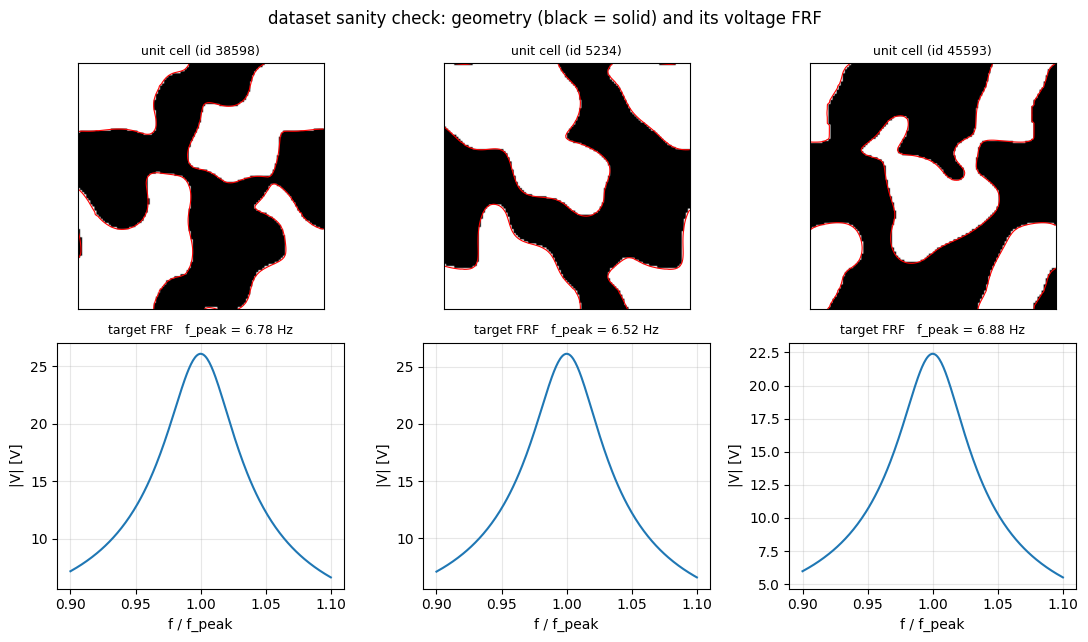

In [3]:
# quick visual sanity check: three random geometry/FRF pairs
import matplotlib.pyplot as plt

_rng = np.random.default_rng(SEED)
_ids = _rng.choice(N_TOTAL, 3, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
for k, i in enumerate(_ids):
    ax = axes[0, k]
    ax.imshow((sdf_raw[i] < 0).T, origin="lower", cmap="gray_r", extent=[-0.1, 1.1, -0.1, 1.1])
    ax.contour(np.linspace(-0.1, 1.1, 120), np.linspace(-0.1, 1.1, 120),
               sdf_raw[i].T, levels=[0.0], colors="red", linewidths=0.8)
    ax.set_title(f"unit cell (id {sample_ids[i]})", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax = axes[1, k]
    ax.plot(FREQ_RATIO, voltage[i])
    ax.set_title(f"target FRF   f_peak = {f_peak[i]:.2f} Hz", fontsize=9)
    ax.set_xlabel("f / f_peak"); ax.set_ylabel("|V| [V]"); ax.grid(alpha=0.3)
fig.suptitle("dataset sanity check: geometry (black = solid) and its voltage FRF")
fig.tight_layout(); plt.show()

## 2 · Normalize and split

**Split — 80% train / 10% validation / 10% test** (chosen for this dataset size; the
project doc suggests 70/15/15, but with 52,570 samples 10% ≈ 5,257 samples is already a
very reliable validation/test size, and more training data helps the model most):

* **train** — the model learns from these samples only;
* **validation** — never trained on; used after every epoch to pick the *best* checkpoint
  and drive the learning-rate schedule;
* **test** — never touched during training; used only at the end for honest evaluation.

Each dataset row is one unique geometry (`sample_id` is unique), so a random row split is
a split *by sample identity* — no leakage between the sets.

**Normalization** (like the reference repo, but fitted on the **train split only**):
each of the three quantities is shifted/scaled by a single global mean/std —
`x → (x − mean)/std`. This preserves curve *shapes* while putting SDF, FRF, and `f_peak`
all near unit scale, which is what neural networks like. The constants are saved to
`scalers.npz` so generated samples can always be converted back to physical units.

In [4]:
# === NORMALIZE & SPLIT ======================================================
perm = np.random.default_rng(SEED).permutation(N_TOTAL)
n_train = int(round(TRAIN_FRAC * N_TOTAL))
n_val   = int(round(VAL_FRAC * N_TOTAL))
train_idx, val_idx, test_idx = perm[:n_train], perm[n_train:n_train + n_val], perm[n_train + n_val:]
print(f"split: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test")

# scalers fitted on the training split only
SDF_MEAN, SDF_STD = float(sdf_raw[train_idx].mean()), float(sdf_raw[train_idx].std())
V_MEAN,   V_STD   = float(voltage[train_idx].mean()), float(voltage[train_idx].std())
FP_MEAN,  FP_STD  = float(f_peak[train_idx].mean()),  float(f_peak[train_idx].std())
print(f"sdf:     mean {SDF_MEAN:+.4f}  std {SDF_STD:.4f}")
print(f"voltage: mean {V_MEAN:+.2f} V  std {V_STD:.2f} V")
print(f"f_peak:  mean {FP_MEAN:+.2f} Hz std {FP_STD:.2f} Hz")

x_all = (sdf_raw - SDF_MEAN) / SDF_STD                     # (N,120,120) normalized SDF
cond_all = np.concatenate([(voltage - V_MEAN) / V_STD,
                           ((f_peak - FP_MEAN) / FP_STD)[:, None]], axis=1)  # (N,257)
COND_LEN = cond_all.shape[1]

# range of normalized SDF values — used to clip x0-predictions during sampling
X_MIN, X_MAX = float(x_all[train_idx].min()), float(x_all[train_idx].max())
print(f"normalized sdf range: [{X_MIN:.2f}, {X_MAX:.2f}]")

np.savez(os.path.join(OUT_DIR, "scalers.npz"),
         sdf_mean=SDF_MEAN, sdf_std=SDF_STD, v_mean=V_MEAN, v_std=V_STD,
         fp_mean=FP_MEAN, fp_std=FP_STD, x_min=X_MIN, x_max=X_MAX,
         freq_ratio=FREQ_RATIO)
np.savez(os.path.join(OUT_DIR, "split_indices.npz"),
         train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
         train_ids=sample_ids[train_idx], val_ids=sample_ids[val_idx],
         test_ids=sample_ids[test_idx], seed=SEED)

from torch.utils.data import TensorDataset, DataLoader

def _make_ds(idx):
    return TensorDataset(torch.from_numpy(x_all[idx][:, None, :, :]),  # (n,1,120,120)
                         torch.from_numpy(cond_all[idx]))              # (n,257)

train_ds, val_ds, test_ds = _make_ds(train_idx), _make_ds(val_idx), _make_ds(test_idx)
pin = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=512,        shuffle=False, pin_memory=pin)
print(f"{len(train_loader)} training batches per epoch (batch size {BATCH_SIZE})")

split: 42056 train / 5257 val / 5257 test


sdf:     mean -0.0236  std 0.0925
voltage: mean +13.26 V  std 5.91 V
f_peak:  mean +7.60 Hz std 0.85 Hz


normalized sdf range: [-4.95, 4.54]


658 training batches per epoch (batch size 64)


## 3 · The model

**Diffusion in one paragraph.** During training we take a real geometry (SDF image), mix in
a random amount of Gaussian noise (from "barely noisy" to "pure noise", indexed by a
timestep `t ∈ [0, 500)`), and train a neural network to predict *what noise was added*,
given the noisy image, `t`, **and the target FRF**. At design time we run the process in
reverse: start from pure noise and remove the predicted noise step by step — but the
network was conditioned on *your* FRF, so it steers the image toward geometries whose
response matches it. Because the start is random, each run yields a *different* valid
candidate — exactly what we want for a one-to-many inverse problem.

**Classifier-free guidance (CFG).** During training the condition is hidden 10% of the
time, so the same network also learns an unconditional model. At sampling time the two
predictions are extrapolated: `noise = (1+w)·conditional − w·unconditional`. Larger `w`
follows the target FRF more aggressively (at some cost of diversity); `w ≈ 2–6` worked
well in the reference paper.

**Architecture** (mirrors `UNetTimeStep` in the SDFGeoDesign repo):

* condition encoder — 1-D CNN reads the 256-point FRF curve, a small MLP reads `f_peak`;
  their features merge into one 128-d conditioning vector;
* residual U-Net on 1×120×120 images, 4 resolution levels (120/60/30/15), channels
  32/64/128/256, self-attention on the two coarsest levels; sinusoidal timestep embedding;
  the timestep + condition vectors are injected into **every** residual block
  (channel-concatenated, as in the reference code, with the CFG mask zeroing the condition).

In [5]:
# === MODEL ==================================================================
import math
import torch.nn as nn
import torch.nn.functional as nnF


def timestep_embedding(timesteps, embed_dim, max_period=10000.0):
    """Sinusoidal timestep embedding (Transformer-style), as in the reference repo."""
    half = embed_dim // 2
    freqs = torch.exp(-math.log(max_period) *
                      torch.arange(half, dtype=torch.float32) / half).to(timesteps.device)
    args = timesteps[:, None].float() * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if embed_dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb


class CondEncoder(nn.Module):
    """(FRF curve 256 pts + f_peak scalar) -> one conditioning vector of size cond_dim."""

    def __init__(self, n_freq=256, cond_dim=128):
        super().__init__()
        self.n_freq = n_freq
        self.frf_cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, stride=2, padding=2), nn.SiLU(),    # 256 -> 128
            nn.Conv1d(32, 64, 5, stride=2, padding=2), nn.SiLU(),   # 128 -> 64
            nn.Conv1d(64, 128, 3, stride=2, padding=1), nn.SiLU(),  # 64  -> 32
            nn.Conv1d(128, 128, 3, stride=2, padding=1), nn.SiLU(), # 32  -> 16
        )
        self.frf_out = nn.Linear(128 * (n_freq // 16), cond_dim)
        self.fp_mlp = nn.Sequential(nn.Linear(1, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU())
        self.merge = nn.Sequential(nn.Linear(cond_dim + 64, cond_dim), nn.SiLU(),
                                   nn.Linear(cond_dim, cond_dim))

    def forward(self, c):                      # c: (B, n_freq + 1)
        frf, fp = c[:, :self.n_freq], c[:, self.n_freq:]
        h = self.frf_cnn(frf[:, None, :])      # (B, 128, n_freq/16)
        h = self.frf_out(h.flatten(1))         # (B, cond_dim)
        return self.merge(torch.cat([h, self.fp_mlp(fp)], dim=1))


class ResidualBlockTS(nn.Module):
    """Residual conv block with timestep + condition injection (reference: ResidualBlockConvTimeStep).
    The CFG mask multiplies the condition embedding: mask 1 = conditioned, 0 = unconditioned."""

    def __init__(self, ch_in, ch_out, time_dim, cond_dim, groups=8, dropout=None):
        super().__init__()
        lay1 = [nn.GroupNorm(groups, ch_in), nn.SiLU()]
        if dropout:
            lay1.append(nn.Dropout(dropout))
        lay1.append(nn.Conv2d(ch_in, ch_out, 3, padding="same"))
        self.conv1 = nn.Sequential(*lay1)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, ch_out))
        self.cond_proj = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, ch_out))
        self.conv_concat = nn.Conv2d(3 * ch_out, ch_out, 3, padding="same")
        lay2 = [nn.GroupNorm(groups, ch_out), nn.SiLU()]
        if dropout:
            lay2.append(nn.Dropout(dropout))
        lay2.append(nn.Conv2d(ch_out, ch_out, 3, padding="same"))
        self.conv2 = nn.Sequential(*lay2)
        self.shortcut = nn.Conv2d(ch_in, ch_out, 1) if ch_in != ch_out else nn.Identity()

    def forward(self, x, t_emb, c_emb, mask):
        h = self.conv1(x)
        te = self.time_proj(t_emb)
        ce = self.cond_proj(c_emb) * mask[:, None]
        h = self.conv_concat(torch.cat([
            h,
            te[:, :, None, None].expand(-1, -1, h.shape[2], h.shape[3]),
            ce[:, :, None, None].expand(-1, -1, h.shape[2], h.shape[3])], dim=1))
        h = self.conv2(h)
        return h + self.shortcut(x)


class MultiAttentionBlock(nn.Module):
    """Multi-head self-attention over spatial positions (reference: MultiAttentionBlock)."""

    def __init__(self, channels, num_heads=4, groups=8):
        super().__init__()
        assert channels % num_heads == 0
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(groups, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1, bias=False)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        q, k, v = self.qkv(self.norm(x)).reshape(B * self.num_heads, -1, H * W).chunk(3, dim=1)
        scale = 1.0 / math.sqrt(math.sqrt(C // self.num_heads))
        attn = torch.einsum("bct,bcs->bts", q * scale, k * scale).softmax(dim=-1)
        h = torch.einsum("bts,bcs->bct", attn, v).reshape(B, -1, H, W)
        return self.proj(h) + x


class DownSample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class UpSample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        return self.conv(self.up(x))


class ConditionalUNet(nn.Module):
    """Noise estimator eps(x_t, t, condition) — port of the reference UNetTimeStep with the
    label-MLP replaced by CondEncoder (FRF 1-D CNN + f_peak MLP)."""

    def __init__(self, base_ch=32, ch_mults=(1, 2, 4, 8), attn=(False, False, True, True),
                 num_res_blocks=1, num_heads=4, groups=8, cond_dim=128,
                 n_freq=256, dropout=None):
        super().__init__()
        chs = [base_ch * m for m in ch_mults]
        time_dim = base_ch * 4
        self.base_ch = base_ch
        self.time_mlp = nn.Sequential(nn.Linear(base_ch, time_dim), nn.SiLU(),
                                      nn.Linear(time_dim, time_dim))
        self.cond_encoder = CondEncoder(n_freq=n_freq, cond_dim=cond_dim)
        self.first_conv = nn.Conv2d(1, base_ch, 3, padding=1)

        def res(ci, co):
            return ResidualBlockTS(ci, co, time_dim, cond_dim, groups=groups, dropout=dropout)

        self.encoder, skip_chs, enc_skip = nn.ModuleList(), [], []
        for i, ch in enumerate(chs):
            ci = base_ch if i == 0 else chs[i - 1]
            self.encoder.append(res(ci, ch))
            if attn[i]:
                self.encoder.append(MultiAttentionBlock(ch, num_heads, groups))
            skip_chs.append(ch); enc_skip.append(len(self.encoder) - 1)
            for _ in range(1, num_res_blocks):
                self.encoder.append(res(ch, ch))
                if attn[i]:
                    self.encoder.append(MultiAttentionBlock(ch, num_heads, groups))
                skip_chs.append(ch); enc_skip.append(len(self.encoder) - 1)
            if i != len(chs) - 1:
                self.encoder.append(DownSample(ch))
        self.enc_skip = torch.zeros(len(self.encoder), dtype=torch.bool)
        self.enc_skip[enc_skip] = True

        self.bottleneck = nn.ModuleList([res(chs[-1], chs[-1]),
                                         MultiAttentionBlock(chs[-1], num_heads, groups),
                                         res(chs[-1], chs[-1])])

        self.decoder, dec_skip = nn.ModuleList(), []
        for i in reversed(range(len(chs))):
            ci = (chs[-1] if i == len(chs) - 1 else chs[i + 1]) + skip_chs.pop()
            self.decoder.append(res(ci, chs[i]))
            dec_skip.append(len(self.decoder) - 1)
            if attn[i]:
                self.decoder.append(MultiAttentionBlock(chs[i], num_heads, groups))
            for _ in range(1, num_res_blocks):
                self.decoder.append(res(chs[i] + skip_chs.pop(), chs[i]))
                dec_skip.append(len(self.decoder) - 1)
                if attn[i]:
                    self.decoder.append(MultiAttentionBlock(chs[i], num_heads, groups))
            if i != 0:
                self.decoder.append(UpSample(chs[i]))
        self.dec_skip = torch.zeros(len(self.decoder), dtype=torch.bool)
        self.dec_skip[dec_skip] = True

        self.out = nn.Sequential(nn.GroupNorm(groups, chs[0]), nn.SiLU(),
                                 nn.Conv2d(chs[0], 1, 3, padding=1))

    def forward(self, x, timesteps, c, mask):
        """x (B,1,H,W) noisy SDF · timesteps (B,) · c (B,257) raw condition · mask (B,) CFG"""
        t_emb = self.time_mlp(timestep_embedding(timesteps, self.base_ch))
        c_emb = self.cond_encoder(c)
        mask = mask.float()
        skips = []
        x = self.first_conv(x)
        for is_skip, layer in zip(self.enc_skip, self.encoder):
            x = layer(x, t_emb, c_emb, mask) if isinstance(layer, ResidualBlockTS) else layer(x)
            if is_skip:
                skips.append(x)
        for layer in self.bottleneck:
            x = layer(x, t_emb, c_emb, mask) if isinstance(layer, ResidualBlockTS) else layer(x)
        for is_skip, layer in zip(self.dec_skip, self.decoder):
            if is_skip:
                x = torch.cat([x, skips.pop()], dim=1)
            x = layer(x, t_emb, c_emb, mask) if isinstance(layer, ResidualBlockTS) else layer(x)
        return self.out(x)


MODEL_KWARGS = dict(base_ch=FIRST_CONV_CHANNELS, ch_mults=tuple(CHANNEL_MULTIPLIERS),
                    attn=tuple(HAS_ATTENTION), num_res_blocks=NUM_RES_BLOCKS,
                    num_heads=NUM_HEADS, groups=NORM_GROUPS, cond_dim=COND_DIM,
                    n_freq=len(FREQ_RATIO))
model = ConditionalUNet(**MODEL_KWARGS).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ConditionalUNet parameters: {n_params/1e6:.2f} M")

ConditionalUNet parameters: 17.25 M


In [6]:
# === DIFFUSION ==============================================================
from tqdm.auto import tqdm


def beta_scheduler(T, kind="linear", s=0.008):
    if kind == "linear":
        scale = 1000 / T
        return torch.linspace(scale * 1e-4, scale * 0.02, T)
    if kind == "cosine":  # Nichol & Dhariwal 2021
        x = torch.linspace(0, T, T + 1, dtype=torch.float64)
        ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
        ac = ac / ac[0]
        return torch.clip(1 - (ac[1:] / ac[:-1]), 0, 0.999).float()
    raise ValueError(kind)


class GaussianDiffusion:
    """DDPM with classifier-free guidance — port of the reference GaussianDiffusion.
    Guidance: eps = (1+w)*eps_cond - w*eps_uncond  (w=0: conditional only, w=-1: unconditional).
    x0-predictions are clipped to the true normalized-SDF range [x_clip_min, x_clip_max]."""

    def __init__(self, img_shape, timesteps=500, beta_schedule="linear",
                 x_clip_min=None, x_clip_max=None):
        self.img_shape, self.timesteps = img_shape, timesteps
        self.x_clip = (x_clip_min, x_clip_max)
        self.betas = beta_scheduler(timesteps, beta_schedule)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = nnF.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod - 1)
        self.posterior_variance = (self.betas * (1.0 - self.alphas_cumprod_prev)
                                   / (1.0 - self.alphas_cumprod))
        self.posterior_log_variance_clipped = torch.log(
            torch.cat([self.posterior_variance[1:2], self.posterior_variance[1:]]))
        self.posterior_mean_coef1 = (self.betas * torch.sqrt(self.alphas_cumprod_prev)
                                     / (1.0 - self.alphas_cumprod))
        self.posterior_mean_coef2 = ((1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas)
                                     / (1.0 - self.alphas_cumprod))

    def _extract(self, a, t, x_shape):
        out = a.to(t.device).gather(0, t).float()
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0, t, noise):
        return (self._extract(self.sqrt_alphas_cumprod, t, x0.shape) * x0 +
                self._extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape) * noise)

    def train_losses(self, model, x0, t, c, mask):
        noise = torch.randn_like(x0)
        x_t = self.q_sample(x0, t, noise)
        pred = model(x_t, t, c, mask)
        return nnF.mse_loss(noise.float(), pred.float())

    def _pred_noise_cfg(self, model, x_t, t, c, w):
        b = x_t.shape[0]
        if w == 0:
            return model(x_t, t, c, torch.ones(b, device=x_t.device))
        if w == -1:
            return model(x_t, t, c, torch.zeros(b, device=x_t.device))
        eps_c = model(x_t, t, c, torch.ones(b, device=x_t.device))
        eps_u = model(x_t, t, c, torch.zeros(b, device=x_t.device))
        return (1 + w) * eps_c - w * eps_u

    def _clip_x0(self, x0):
        if self.x_clip[0] is not None:
            x0 = torch.clamp(x0, min=self.x_clip[0], max=self.x_clip[1])
        return x0

    @torch.no_grad()
    def p_sample_loop(self, model, labels, w=2.0, progress=True):
        """Full ancestral DDPM sampling (all `timesteps` steps)."""
        b = labels.shape[0]
        dvc = next(model.parameters()).device
        labels = labels.to(dvc)
        img = torch.randn((b, *self.img_shape), device=dvc)
        it = reversed(range(self.timesteps))
        if progress:
            it = tqdm(it, total=self.timesteps, desc="DDPM sampling")
        for i in it:
            t = torch.full((b,), i, device=dvc, dtype=torch.long)
            eps = self._pred_noise_cfg(model, img, t, labels, w)
            x0 = self._clip_x0(
                self._extract(self.sqrt_recip_alphas_cumprod, t, img.shape) * img -
                self._extract(self.sqrt_recipm1_alphas_cumprod, t, img.shape) * eps)
            mean = (self._extract(self.posterior_mean_coef1, t, img.shape) * x0 +
                    self._extract(self.posterior_mean_coef2, t, img.shape) * img)
            logvar = self._extract(self.posterior_log_variance_clipped, t, img.shape)
            nonzero = (t != 0).float().view(-1, 1, 1, 1)
            img = mean + nonzero * (0.5 * logvar).exp() * torch.randn_like(img)
        return img.cpu().numpy()

    @torch.no_grad()
    def ddim_sample(self, model, labels, ddim_steps=100, w=2.0, eta=0.0, progress=True):
        """Fast deterministic DDIM sampling (Song et al. 2020), as in the reference repo."""
        b = labels.shape[0]
        dvc = next(model.parameters()).device
        labels = labels.to(dvc)
        step = self.timesteps // ddim_steps
        seq = np.asarray(list(range(0, self.timesteps, step))) + 1
        seq_prev = np.append(np.array([0]), seq[:-1])
        img = torch.randn((b, *self.img_shape), device=dvc)
        it = reversed(range(ddim_steps))
        if progress:
            it = tqdm(it, total=ddim_steps, desc="DDIM sampling")
        for i in it:
            t = torch.full((b,), seq[i], device=dvc, dtype=torch.long)
            t_prev = torch.full((b,), seq_prev[i], device=dvc, dtype=torch.long)
            ac_t = self._extract(self.alphas_cumprod, t, img.shape)
            ac_prev = self._extract(self.alphas_cumprod, t_prev, img.shape)
            eps = self._pred_noise_cfg(model, img, t, labels, w)
            x0 = self._clip_x0((img - torch.sqrt(1.0 - ac_t) * eps) / torch.sqrt(ac_t))
            sigma = eta * torch.sqrt((1 - ac_prev) / (1 - ac_t) * (1 - ac_t / ac_prev))
            dir_xt = torch.sqrt(1 - ac_prev - sigma ** 2) * eps
            img = torch.sqrt(ac_prev) * x0 + dir_xt + sigma * torch.randn_like(img)
        return img.cpu().numpy()


diffusion = GaussianDiffusion(img_shape=(1, 120, 120), timesteps=TIMESTEPS,
                              beta_schedule=BETA_SCHEDULE, x_clip_min=X_MIN, x_clip_max=X_MAX)
print(f"diffusion: T={TIMESTEPS}, schedule={BETA_SCHEDULE}, x0 clip [{X_MIN:.2f}, {X_MAX:.2f}]")

diffusion: T=500, schedule=linear, x0 clip [-4.95, 4.54]


/home/user/GJ/diffusion/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4 · Training

Each step: pick a batch of geometries, noise them to random timesteps, predict the noise
conditioned on the matching FRFs (condition randomly hidden 10% of the time for CFG), and
minimize the mean-squared error. The printed **loss is that MSE** — expect a fast drop
below ~0.1 and then a slow decline; the *validation* loss decides which checkpoint is kept
as `model_best.ckpt`.

Bookkeeping (all automatic): EMA shadow weights (a slow-moving average of the model —
samples noticeably better than the raw weights), `ReduceLROnPlateau` learning-rate decay,
gradient clipping, bf16 mixed precision, per-epoch CSV log, and resumable checkpoints —
set `TRAIN_FLAG = "continue"` after an interruption, or `"skip"` to go straight to §5.

In [7]:
# === TRAIN ==================================================================
import csv

class EMA:
    """Exponential moving average of model weights (used for sampling)."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)
            else:
                self.shadow[k].copy_(v)


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5,
                                                       patience=8, min_lr=1e-6)
ema = EMA(model, decay=EMA_DECAY)
amp_enabled = USE_AMP and device.type == "cuda"
AMP_DTYPE = torch.bfloat16

LAST_CKPT = os.path.join(OUT_DIR, "model_last.ckpt")
BEST_CKPT = os.path.join(OUT_DIR, "model_best.ckpt")
LOG_CSV   = os.path.join(OUT_DIR, "train_log.csv")
CKPT_EXTRA = dict(config=MODEL_KWARGS, timesteps=TIMESTEPS, beta_schedule=BETA_SCHEDULE,
                  scalers=dict(sdf_mean=SDF_MEAN, sdf_std=SDF_STD, v_mean=V_MEAN, v_std=V_STD,
                               fp_mean=FP_MEAN, fp_std=FP_STD, x_min=X_MIN, x_max=X_MAX))

start_epoch, best_val = 0, float("inf")
if TRAIN_FLAG == "continue" and os.path.exists(LAST_CKPT):
    ck = torch.load(LAST_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); ema.shadow = ck["ema"]
    start_epoch, best_val = ck["epoch"] + 1, ck["best_val"]
    print(f"resuming from epoch {start_epoch} (best val {best_val:.5f})")
elif TRAIN_FLAG == "start" and os.path.exists(BEST_CKPT):
    print(f"WARNING: {OUT_DIR} already holds checkpoints — 'start' will overwrite them. "
          f"Use TRAIN_FLAG='continue' to resume instead.")


def run_loss(x, c):
    x = x.to(device, non_blocking=True)
    c = c.to(device, non_blocking=True)
    b = x.shape[0]
    t = torch.randint(0, TIMESTEPS, (b,), device=device)
    mask = (torch.rand(b, device=device) > P_UNCOND).float()
    with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=amp_enabled):
        return diffusion.train_losses(model, x, t, c, mask), b


@torch.no_grad()
def validate():
    model.eval()
    tot, n = 0.0, 0
    for x, c in val_loader:
        loss, b = run_loss(x, c)
        tot += loss.item() * b; n += b
    return tot / n


if TRAIN_FLAG in ("start", "continue"):
    if not os.path.exists(LOG_CSV) or TRAIN_FLAG == "start":
        with open(LOG_CSV, "w", newline="") as f:
            csv.writer(f).writerow(["epoch", "train_loss", "val_loss", "lr", "seconds"])
    for epoch in range(start_epoch, EPOCHS):
        model.train()
        t0, tot, n = time.time(), 0.0, 0
        for x, c in tqdm(train_loader, leave=False, desc=f"epoch {epoch+1}/{EPOCHS}"):
            loss, b = run_loss(x, c)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            ema.update(model)
            tot += loss.item() * b; n += b
        train_loss, val_loss = tot / n, validate()
        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]["lr"]
        dt = time.time() - t0
        with open(LOG_CSV, "a", newline="") as f:
            csv.writer(f).writerow([epoch, f"{train_loss:.6f}", f"{val_loss:.6f}",
                                    f"{lr_now:.2e}", f"{dt:.1f}"])
        state = dict(model=model.state_dict(), ema=ema.shadow, optimizer=optimizer.state_dict(),
                     scheduler=scheduler.state_dict(), epoch=epoch, best_val=best_val,
                     **CKPT_EXTRA)
        torch.save(state, LAST_CKPT)
        marker = ""
        if val_loss < best_val:
            best_val = val_loss
            state["best_val"] = best_val
            torch.save(state, BEST_CKPT)
            marker = "  <- best"
        print(f"epoch {epoch+1:3d}/{EPOCHS}  train {train_loss:.5f}  val {val_loss:.5f}"
              f"  lr {lr_now:.1e}  {dt:5.1f}s{marker}")
    print(f"\ndone — best validation loss {best_val:.5f}; checkpoints in {OUT_DIR}/")
else:
    print("TRAIN_FLAG='skip' — using existing checkpoints in", OUT_DIR)

epoch   1/200  train 0.03068  val 0.00927  lr 2.0e-04  132.0s  <- best


epoch   2/200  train 0.00797  val 0.00657  lr 2.0e-04  128.8s  <- best


epoch   3/200  train 0.00659  val 0.00615  lr 2.0e-04  127.9s  <- best


epoch   4/200  train 0.00585  val 0.00553  lr 2.0e-04  127.4s  <- best


epoch   5/200  train 0.00484  val 0.00452  lr 2.0e-04  127.1s  <- best


...

epoch 196/200  train 0.00232  val 0.00237  lr 1.0e-06  128.1s


epoch 197/200  train 0.00236  val 0.00236  lr 1.0e-06  128.0s


epoch 198/200  train 0.00235  val 0.00232  lr 1.0e-06  128.6s


epoch 199/200  train 0.00233  val 0.00237  lr 1.0e-06  128.2s


epoch 200/200  train 0.00234  val 0.00239  lr 1.0e-06  128.9s

done — best validation loss 0.00226; checkpoints in runs/diffusion_v1/


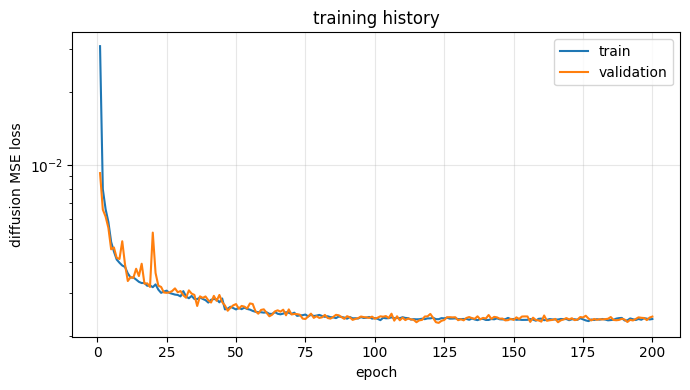

In [8]:
# === LOSS CURVES ============================================================
if os.path.exists(LOG_CSV):
    hist = np.genfromtxt(LOG_CSV, delimiter=",", names=True)
    if hist.size:
        hist = np.atleast_1d(hist)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(hist["epoch"] + 1, hist["train_loss"], label="train")
        ax.plot(hist["epoch"] + 1, hist["val_loss"], label="validation")
        ax.set_xlabel("epoch"); ax.set_ylabel("diffusion MSE loss")
        ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend()
        ax.set_title("training history")
        fig.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, "figures", "loss_curve.png"), dpi=150)
        plt.show()

## 5 · Generate designs for test-set targets

The cells below reload the **best EMA weights from disk** (so they work in a fresh session
with `TRAIN_FLAG = "skip"`), take FRFs from the held-out **test set** as design targets,
and generate several candidate unit cells per target with fast DDIM sampling.

What to look at:

* generated cells should be **crisp, periodic-looking patterns** (black = solid), diverse
  across candidates for the same target — diffusion gives you *a family* of designs;
* the printed **validity rate**: fraction of candidates that form one connected structure
  when tiled 3×3 (the same pre-filter the data campaign used — disconnected cells would be
  rejected by the CAD/mesh stage);
* the true test geometry is shown only as a reference — a *different-looking* candidate is
  not wrong (the inverse problem is one-to-many); the real check is re-running FEM (§6).

Knobs: `GUIDANCE_W` (higher = follows the target FRF harder, less diverse — try 2–6),
`EVAL_DDIM_STEPS` (100 is a good speed/quality point; full 500-step DDPM is available via
`diffusion.p_sample_loop`).

loaded EMA weights from epoch 123 (best val 0.00226)


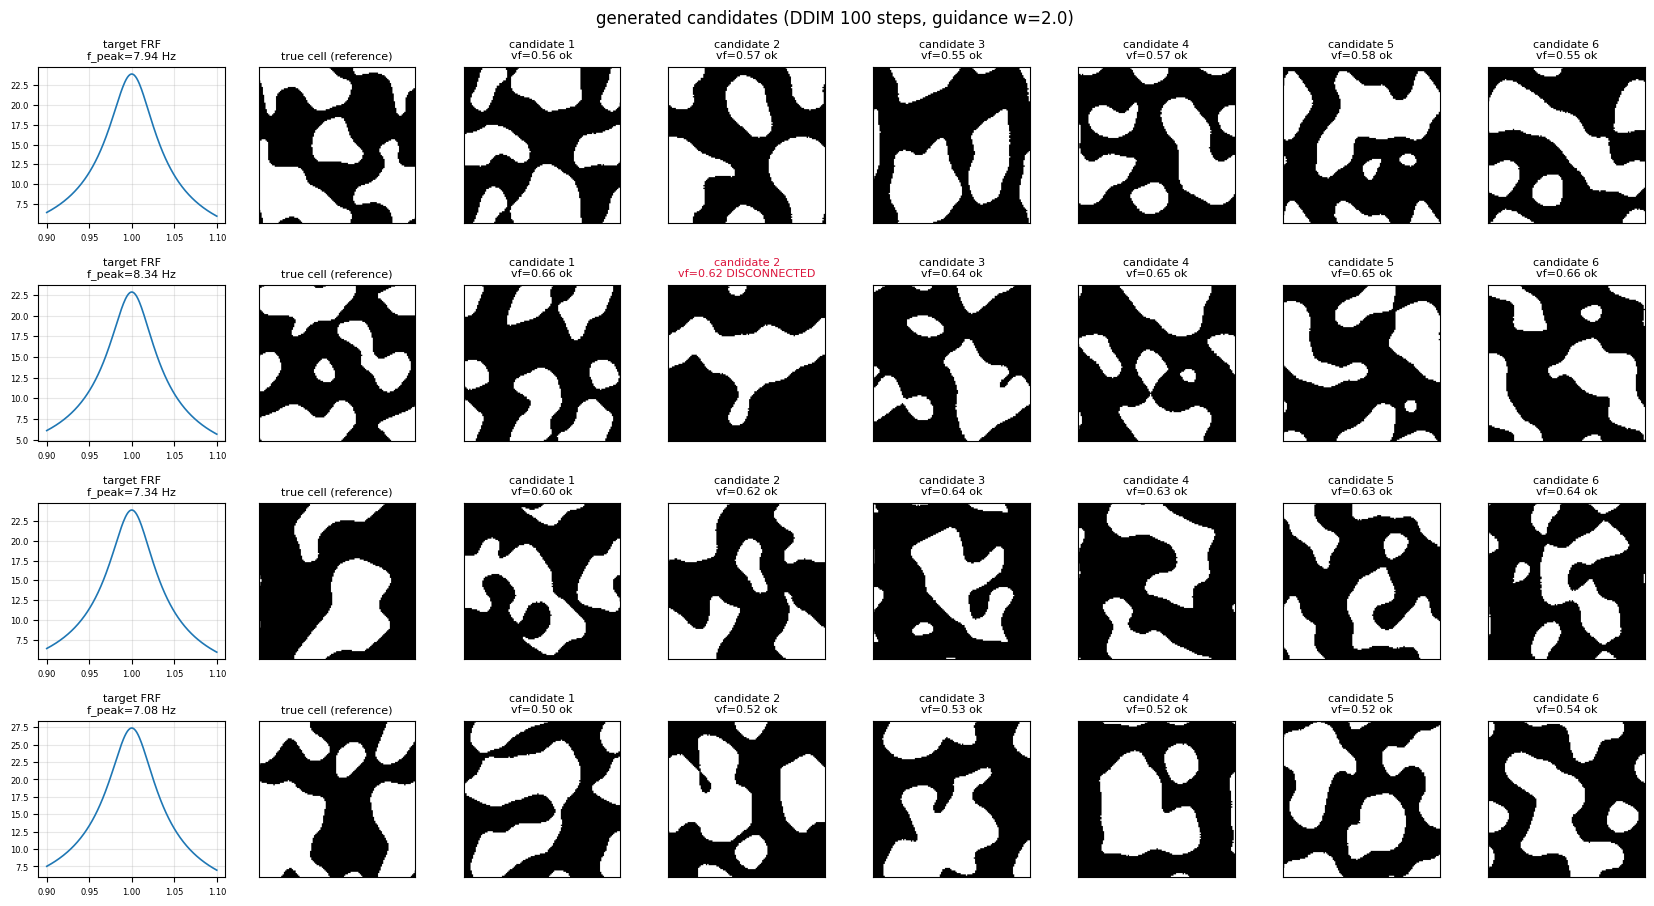

validity (3x3-tiled connectivity): 23/24 = 96% of candidates
saved: runs/diffusion_v1/generated/testset_candidates.npz


In [9]:
# === GENERATE ===============================================================
from scipy import ndimage

ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
gen_model = ConditionalUNet(**ckpt["config"]).to(device)
gen_model.load_state_dict(ckpt["ema"])
gen_model.eval()
print(f"loaded EMA weights from epoch {ckpt['epoch']+1} (best val {ckpt['best_val']:.5f})")

SC = ckpt["scalers"]

def denorm_sdf(x):
    return x * SC["sdf_std"] + SC["sdf_mean"]

def solid_binary(sdf_padded):
    """Solid mask on the unit cell [0,1)² (120×120, periodic grid) from a padded SDF."""
    from scipy.interpolate import RegularGridInterpolator
    ax_pad = np.linspace(-0.1, 1.1, 120)
    ax_unit = np.linspace(0.0, 1.0, 120, endpoint=False)
    itp = RegularGridInterpolator((ax_pad, ax_pad), sdf_padded, method="linear")
    xx, yy = np.meshgrid(ax_unit, ax_unit, indexing="ij")
    return itp(np.column_stack([xx.ravel(), yy.ravel()])).reshape(120, 120) < 0.0

def periodically_connected(binary):
    """One connected solid component when tiled 3×3 (campaign validity pre-filter)."""
    labeled, n = ndimage.label(np.tile(binary, (3, 3)))
    if n == 0:
        return False
    m = binary.shape[0]
    labels = labeled[m:2 * m, m:2 * m][binary]
    return labels.size > 0 and len(np.unique(labels)) == 1


torch.manual_seed(SEED + 1)
rng_eval = np.random.default_rng(SEED + 1)
target_rows = rng_eval.choice(len(test_idx), size=N_TARGETS, replace=False)

all_gen, all_connected = [], []
for row in target_rows:
    cond = torch.from_numpy(cond_all[test_idx[row]][None, :]).repeat(N_CANDIDATES, 1)
    gen_norm = diffusion.ddim_sample(gen_model, cond, ddim_steps=EVAL_DDIM_STEPS,
                                     w=GUIDANCE_W, progress=False)
    all_gen.append(denorm_sdf(gen_norm[:, 0]))

fig, axes = plt.subplots(N_TARGETS, N_CANDIDATES + 2,
                         figsize=(2.1 * (N_CANDIDATES + 2), 2.3 * N_TARGETS))
axes = np.atleast_2d(axes)
ext = [-0.1, 1.1, -0.1, 1.1]
for r, row in enumerate(target_rows):
    gi = test_idx[row]
    ax = axes[r, 0]
    ax.plot(FREQ_RATIO, voltage[gi], lw=1.2)
    ax.set_title(f"target FRF\nf_peak={f_peak[gi]:.2f} Hz", fontsize=8)
    ax.tick_params(labelsize=6); ax.grid(alpha=0.3)
    ax = axes[r, 1]
    ax.imshow((sdf_raw[gi] < 0).T, origin="lower", cmap="gray_r", extent=ext)
    ax.set_title("true cell (reference)", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for k in range(N_CANDIDATES):
        sdf_k = all_gen[r][k]
        b = solid_binary(sdf_k)
        conn = periodically_connected(b)
        all_connected.append(conn)
        ax = axes[r, 2 + k]
        ax.imshow((sdf_k < 0).T, origin="lower", cmap="gray_r", extent=ext)
        ax.set_title(f"candidate {k+1}\nvf={b.mean():.2f} {'ok' if conn else 'DISCONNECTED'}",
                     fontsize=8, color="black" if conn else "crimson")
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"generated candidates (DDIM {EVAL_DDIM_STEPS} steps, guidance w={GUIDANCE_W})")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figures", "generated_gallery.png"), dpi=150)
plt.show()

rate = float(np.mean(all_connected))
print(f"validity (3x3-tiled connectivity): {np.sum(all_connected)}/{len(all_connected)}"
      f" = {rate:.0%} of candidates")

np.savez_compressed(
    os.path.join(OUT_DIR, "generated", "testset_candidates.npz"),
    sdf=np.concatenate(all_gen),
    target_voltage=np.repeat(voltage[test_idx[target_rows]], N_CANDIDATES, axis=0),
    target_f_peak=np.repeat(f_peak[test_idx[target_rows]], N_CANDIDATES),
    target_sample_id=np.repeat(sample_ids[test_idx[target_rows]], N_CANDIDATES),
    guidance_w=GUIDANCE_W, ddim_steps=EVAL_DDIM_STEPS)
print("saved:", os.path.join(OUT_DIR, "generated", "testset_candidates.npz"))

## 6 · Design for *your own* target FRF (+ export for FEM verification)

`design_unit_cells()` is the actual inverse-design entry point: give it any target voltage
curve (256 points on `f/f_peak ∈ [0.9, 1.1]`, in peak volts) and a peak frequency in Hz, get
back candidate unit-cell SDFs.

`export_for_fem()` writes candidates as a **unit-cell dataset npz** in the same convention
notebook 1 produces (`grf` = −SDF resampled to the `[0,1)²` periodic grid, `threshold` = 0,
solid where `grf ≥ threshold`), so the geometries can be verified with the standard FEM
pipeline — follow the recipe in **notebook 2 §2**, pointing `SOURCE_UNIT_CELL_NPZ` at the
exported file (keep the 3×3 tiling flags). The FEM-computed FRF of a good design should
land close to your target; generating many candidates and keeping the best match is the
intended workflow (the paper does the same, re-ranking with a forward surrogate).

Below, as a demonstration, we design for one FRF taken from the test set.

demo target: test sample_id 45330  (f_peak 6.64 Hz)


exported 8 cells -> runs/diffusion_v1/generated/designed_unit_cells.npz   (8/8 pass the 3x3 connectivity pre-filter)


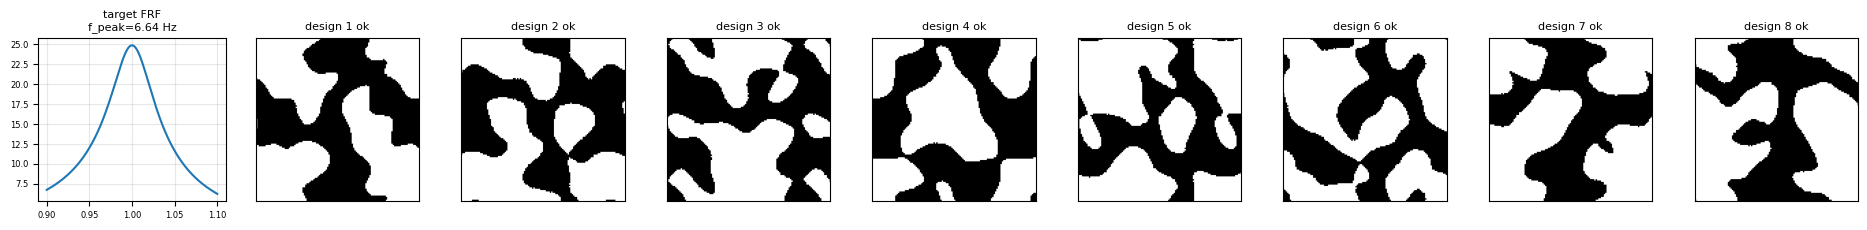

In [10]:
# === INVERSE DESIGN API =====================================================
from skimage import measure


def design_unit_cells(voltage_curve_v, f_peak_hz, n_candidates=8,
                      guidance_w=GUIDANCE_W, ddim_steps=EVAL_DDIM_STEPS, seed=None):
    """Generate candidate unit-cell SDFs for a target voltage FRF.

    voltage_curve_v : (256,) target |V(f)| in peak volts on f/f_peak = linspace(0.9, 1.1, 256)
    f_peak_hz       : desired resonance frequency in Hz (training range ~3.6-9.5 Hz)
    returns         : (n_candidates, 120, 120) SDFs in physical units (negative = solid,
                      domain [-0.1, 1.1]^2 in unit-cell coordinates)
    """
    if seed is not None:
        torch.manual_seed(seed)
    v = (np.asarray(voltage_curve_v, dtype=np.float32) - SC["v_mean"]) / SC["v_std"]
    fp = (float(f_peak_hz) - SC["fp_mean"]) / SC["fp_std"]
    cond = torch.from_numpy(np.concatenate([v, [fp]]).astype(np.float32))
    cond = cond[None, :].repeat(n_candidates, 1)
    gen = diffusion.ddim_sample(gen_model, cond, ddim_steps=ddim_steps,
                                w=guidance_w, progress=True)
    return denorm_sdf(gen[:, 0])


def export_for_fem(sdf_batch, out_path):
    """Write generated SDFs as a unit-cell dataset npz compatible with the FEM pipeline
    (notebook 2). Solid convention: grf >= threshold(=0), i.e. grf = -sdf."""
    from scipy.interpolate import RegularGridInterpolator
    ax_pad = np.linspace(-0.1, 1.1, 120)
    ax_unit = np.linspace(0.0, 1.0, 120, endpoint=False)
    xx, yy = np.meshgrid(ax_unit, ax_unit, indexing="ij")
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    grf, contours = [], []
    for s in sdf_batch:
        itp = RegularGridInterpolator((ax_pad, ax_pad), s, method="linear")
        g = -itp(pts).reshape(120, 120)
        grf.append(g)
        padded = np.pad(g, ((0, 1), (0, 1)), mode="wrap")
        contours.append([c / 120.0 for c in
                         measure.find_contours(padded, level=0.0, positive_orientation="high")])
    grf = np.asarray(grf)
    binary = grf >= 0.0
    connected = np.array([periodically_connected(b) for b in binary])
    contours_arr = np.empty(len(contours), dtype=object)   # ragged list -> object array
    for i, c in enumerate(contours):
        contours_arr[i] = c
    np.savez_compressed(
        out_path, grf=grf, binary=binary, sdf=np.asarray(sdf_batch),
        threshold=np.zeros(len(grf)), volume_fraction=binary.mean(axis=(1, 2)),
        contours=contours_arr,
        cell_size_m=np.tile([0.1, 0.1], (len(grf), 1)),
        tile_counts=np.tile([3, 3], (len(grf), 1)).astype(np.int64))
    print(f"exported {len(grf)} cells -> {out_path}   "
          f"({connected.sum()}/{len(grf)} pass the 3x3 connectivity pre-filter)")
    return connected


# --- demo: design for one held-out target -----------------------------------
demo_gi = test_idx[int(rng_eval.integers(len(test_idx)))]
print(f"demo target: test sample_id {sample_ids[demo_gi]}  (f_peak {f_peak[demo_gi]:.2f} Hz)")
designs = design_unit_cells(voltage[demo_gi], f_peak[demo_gi],
                            n_candidates=8, seed=SEED + 2)
connected = export_for_fem(designs, os.path.join(OUT_DIR, "generated", "designed_unit_cells.npz"))

n_show = len(designs)
fig, axes = plt.subplots(1, n_show + 1, figsize=(2.1 * (n_show + 1), 2.4))
axes[0].plot(FREQ_RATIO, voltage[demo_gi]); axes[0].grid(alpha=0.3)
axes[0].set_title(f"target FRF\nf_peak={f_peak[demo_gi]:.2f} Hz", fontsize=8)
axes[0].tick_params(labelsize=6)
for k in range(n_show):
    axes[1 + k].imshow((designs[k] < 0).T, origin="lower", cmap="gray_r",
                       extent=[-0.1, 1.1, -0.1, 1.1])
    axes[1 + k].set_title(f"design {k+1} {'ok' if connected[k] else 'DISCONNECTED'}",
                          fontsize=8, color="black" if connected[k] else "crimson")
    axes[1 + k].set_xticks([]); axes[1 + k].set_yticks([])
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figures", "inverse_design_demo.png"), dpi=150)
plt.show()

## 7 · Where to go from here

* **Close the loop with FEM** — run the pipeline (notebook 2 §2 recipe) on
  `runs/diffusion_v1/generated/designed_unit_cells.npz`, compare the computed FRFs against
  the targets (relative L2 error + peak-frequency error), and keep the best candidates.
  This is the honest metric; connectivity/volume-fraction above are only cheap proxies.
* **Tune guidance** — sweep `GUIDANCE_W ∈ {0, 2, 4, 6}`: higher usually tracks the target
  better but reduces diversity and can over-sharpen geometry.
* **Train longer / bigger** — if the validation loss is still falling at 200 epochs, raise
  `EPOCHS`; `FIRST_CONV_CHANNELS = 64` doubles capacity if the GPU allows.
* **Forward surrogate re-ranking** (paper's approach) — train a forward model
  (geometry → FRF, e.g. their Neural Operator Transformer) to rank hundreds of candidates
  in milliseconds without FEM; a natural "notebook 4".
* **Latent diffusion** (project doc §6.2) — an autoencoder + diffusion in latent space
  would cut sampling cost; worth it mainly if you later move to higher resolutions.